In [300]:
import matplotlib.pyplot as plt
import numpy as np

In [301]:
import pandas as pd


data = pd.read_csv('data/ecommerce_sales.csv')

df = pd.DataFrame(data)
df

,Order_ID,Customer_ID,Date,City,Category,Product,Price,Quantity,Discount,Payment,Order_Status
0,ORD2025006680,C00497,2026-03-28,Nashik,Beauty,Lip Balm,3510,1,15.0,Wallet,Delivered
1,ORD2025003291,C01066,2025-07-05,Solapur,Electronics,Headphones,6510,3,10.0,UPI,Shipped
2,ORD2025006559,C02179,2025-04-14,Pune,Home & Kitchen,Cookware Set,3060,6,5.0,Credit Card,Cancelled
3,ORD2025007927,C01758,2025-06-20,Solapur,Home & Kitchen,Mixer Grinder,11250,4,20.0,UPI,Delivered
4,ORD2025005665,C00708,2025-10-01,Kolhapur,Clothing,Track Pants,900,2,0.0,Credit Card,Cancelled
...,...,...,...,...,...,...,...,...,...,...,...
15070,ORD2025005192,C01390,2026-05-13,Mumbai,Electronics,Power Bank,29930,2,25.0,UPI,Returned
15071,ORD2025013419,C00592,2025-08-24,Nashik,Clothing,Sneakers,6080,1,20.0,Credit Card,Delivered
15072,ORD2025005391,C00274,2025-09-09,Thane,Electronics,Gaming Mouse,28130,2,15.0,Net Banking,Delivered
15073,ORD2025000861,C01286,2025-12-08,Ahmednagar,Books,Exam Guide,1300,3,10.0,UPI,Delivered


In [302]:
#checking for duplicates

print("Duplicate rows: ", df.duplicated().sum())
print()
print(df[df.duplicated()])

Duplicate rows:  75

            Order_ID Customer_ID        Date      City        Category  \
232    ORD2025000933      C00847  2025-06-22    Nashik     Electronics   
1123   ORD2025003976      C00281  2026-01-07    Mumbai           Books   
1274   ORD2025007827      C01220  2025-10-04    Mumbai        Clothing   
2255   ORD2025011361      C02103  2025-08-27  Kolhapur          Beauty   
2311   ORD2025001796      C00276  2025-02-26    Nashik  Home & Kitchen   
...              ...         ...         ...       ...             ...   
14317  ORD2025005971      C00651  2025-08-20    Nashik  Home & Kitchen   
14605  ORD2025011737      C01364  2025-08-21    Mumbai     Electronics   
14662  ORD2025000150      C01364  2025-04-03    Mumbai        Clothing   
14744  ORD2025014868      C00513  2025-01-10    Mumbai     Electronics   
14859  ORD2025003018      C00404  2025-06-16    Mumbai        Clothing   

                   Product  Price  Quantity  Discount      Payment  \
232    Mechanical Ke

In [303]:
df[df.duplicated(keep=False)].sort_values("Order_ID")

,Order_ID,Customer_ID,Date,City,Category,Product,Price,Quantity,Discount,Payment,Order_Status
34,ORD2025000150,C01364,2025-04-03,Mumbai,Clothing,Sneakers,4480,1,25.0,UPI,Cancelled
14662,ORD2025000150,C01364,2025-04-03,Mumbai,Clothing,Sneakers,4480,1,25.0,UPI,Cancelled
2462,ORD2025000170,C00010,2025-12-24,Nashik,Electronics,Smartwatch,5760,1,0.0,Net Banking,Delivered
138,ORD2025000170,C00010,2025-12-24,Nashik,Electronics,Smartwatch,5760,1,0.0,Net Banking,Delivered
106,ORD2025000252,C01057,2025-06-14,Ahmednagar,Home & Kitchen,Air Fryer,16750,3,0.0,Wallet,Delivered
...,...,...,...,...,...,...,...,...,...,...,...
10113,ORD2025014425,C00176,2026-03-09,Mumbai,Electronics,Bluetooth Speaker,9480,1,0.0,Cash on Delivery,Delivered
7099,ORD2025014483,C01148,2025-05-13,Kolhapur,Electronics,Mechanical Keyboard,21850,3,0.0,Credit Card,Delivered
11823,ORD2025014483,C01148,2025-05-13,Kolhapur,Electronics,Mechanical Keyboard,21850,3,0.0,Credit Card,Delivered
2220,ORD2025014868,C00513,2025-01-10,Mumbai,Electronics,Headphones,14840,3,0.0,Credit Card,Cancelled


In [304]:
#Checking for nulls

df.isnull().sum()

Order_ID          0
Customer_ID       0
Date              0
City             90
Category          0
Product           0
Price             0
Quantity          0
Discount        180
Payment         120
Order_Status      0
dtype: int64

In [305]:
#checking datatypes

print(df.dtypes)
print()
df['Date'].head(20)

Order_ID         object
Customer_ID      object
Date             object
City             object
Category         object
Product          object
Price             int64
Quantity          int64
Discount        float64
Payment          object
Order_Status     object
dtype: object



0     2026-03-28
1     2025-07-05
2     2025-04-14
3     2025-06-20
4     2025-10-01
5     2026-03-31
6     2026-03-01
7     2025-04-13
8     2025-03-10
9     2025-07-21
10    2026-06-22
11    2025-05-28
12    2025-02-01
13    2025-06-06
14    2025-08-19
15    2026-06-09
16    2025-12-02
17    2026-06-24
18    2025-01-13
19    2025-08-11
Name: Date, dtype: object

In [306]:
#Finding Invalid Values

print(df['Quantity'].describe())
print(df[df['Quantity'] <= 0])
print()

print(df['Price'].describe())
print(df[df['Price'] <= 0])
print()

print(df['Discount'].describe())
print(df[df['Discount'] < 0])
df[df["Discount"] > 100]

count    15075.000000
mean         2.162056
std          1.345785
min         -1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          6.000000
Name: Quantity, dtype: float64
            Order_ID Customer_ID        Date         City        Category  \
205    ORD2025011961      C00261  2025-11-22       Mumbai     Electronics   
2118   ORD2025011034      C01910  2025-10-05          NaN     Electronics   
2281   ORD2025014500      C00334  2025-06-03  Navi Mumbai        Clothing   
2848   ORD2025001584      C01802  2026-06-12        Thane        Clothing   
3049   ORD2025012264      C01293  2026-05-06       Nagpur        Clothing   
3064   ORD2025008087      C01793  2025-09-20         Pune        Clothing   
5664   ORD2025001442      C00686  2025-01-19         Pune        Clothing   
6708   ORD2025009271      C01157  2025-04-30       Mumbai     Electronics   
6956   ORD2025011171      C01347  2025-12-21       Nashik     Electronics   
6991   ORD2025012309   

,Order_ID,Customer_ID,Date,City,Category,Product,Price,Quantity,Discount,Payment,Order_Status


In [307]:
df[df["Quantity"] <= 0][
    ["Order_ID", "Customer_ID", "Quantity", "Price", "Order_Status"]
]

,Order_ID,Customer_ID,Quantity,Price,Order_Status
205,ORD2025011961,C00261,0,12140,Delivered
2118,ORD2025011034,C01910,0,30080,Delivered
2281,ORD2025014500,C00334,-1,1000,Cancelled
2848,ORD2025001584,C01802,-1,2020,Delivered
3049,ORD2025012264,C01293,-1,2630,Returned
3064,ORD2025008087,C01793,0,2450,Returned
5664,ORD2025001442,C00686,0,3110,Cancelled
6708,ORD2025009271,C01157,0,8700,Delivered
6956,ORD2025011171,C01347,-1,27170,Delivered
6991,ORD2025012309,C00540,-1,4670,Shipped


In [308]:
df[df["Price"] <= 0][
    ["Order_ID", "Customer_ID", "Quantity", "Price", "Order_Status"]
]

,Order_ID,Customer_ID,Quantity,Price,Order_Status
144,ORD2025009080,C02317,2,0,Cancelled
366,ORD2025006105,C00827,2,0,Cancelled
752,ORD2025012471,C00189,1,-500,Delivered
2542,ORD2025009441,C00631,1,-500,Cancelled
2775,ORD2025010591,C00393,2,0,Shipped
5899,ORD2025013155,C01082,2,0,Delivered
7449,ORD2025005139,C00603,2,0,Cancelled
7876,ORD2025014732,C01059,2,-500,Returned
8177,ORD2025009643,C01819,3,-500,Cancelled
9186,ORD2025000144,C01394,1,-500,Shipped


In [309]:
#Check Categorical Consistency

df['Category'].unique()
df['City'].unique()
df['Payment'].unique()

df['Category'].value_counts(dropna=False)
df['City'].value_counts(dropna=False)
df['Payment'].value_counts(dropna=False)

Payment
UPI                 6055
Credit Card         2960
Debit Card          2351
Cash on Delivery    1471
Wallet              1077
Net Banking         1041
NaN                  120
Name: count, dtype: int64

In [310]:
#Fixing Categorical Inconsistency

df['Category'] = df['Category'].str.strip().str.title()
df['Category'].value_counts()

Category
Electronics       4535
Clothing          3646
Home & Kitchen    2950
Beauty            2186
Books             1758
Name: count, dtype: int64

In [311]:
df['City'] = df['City'].str.strip().str.title()
df['City'].value_counts()

City
Mumbai         3096
Pune           2571
Thane          1695
Nashik         1679
Nagpur         1442
Navi Mumbai    1214
Kolhapur        964
Aurangabad      821
Ahmednagar      766
Solapur         737
Name: count, dtype: int64

In [312]:
#Converting df['Date'] to datetime object

df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
print(df.dtypes)
print("Any nulls : ", df["Date"].isna().sum())

Order_ID                object
Customer_ID             object
Date            datetime64[ns]
City                    object
Category                object
Product                 object
Price                    int64
Quantity                 int64
Discount               float64
Payment                 object
Order_Status            object
dtype: object
Any nulls :  0


In [313]:
df["Date"].head(10)

0   2026-03-28
1   2025-07-05
2   2025-04-14
3   2025-06-20
4   2025-10-01
5   2026-03-31
6   2026-03-01
7   2025-04-13
8   2025-03-10
9   2025-07-21
Name: Date, dtype: datetime64[ns]

In [314]:
#Checking invalid price and quantity rows

df[df['Quantity']<=0]['Order_Status'].value_counts().sum()

np.int64(18)

In [315]:
df[df['Price']<=0]['Order_Status'].value_counts().sum()

np.int64(12)

In [316]:
#Removing Invalid Price and Quantity rows

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [317]:
print(df[df['Quantity'] <= 0])
print(df[df['Price'] <= 0])

Empty DataFrame
Columns: [Order_ID, Customer_ID, Date, City, Category, Product, Price, Quantity, Discount, Payment, Order_Status]
Index: []
Empty DataFrame
Columns: [Order_ID, Customer_ID, Date, City, Category, Product, Price, Quantity, Discount, Payment, Order_Status]
Index: []


In [318]:
#Checking Discount Column

df['Discount'].describe()

count    14865.000000
mean         9.131853
std          8.058967
min          0.000000
25%          0.000000
50%         10.000000
75%         15.000000
max         30.000000
Name: Discount, dtype: float64

In [319]:
df["Discount"].isnull().sum()

np.int64(180)

In [320]:
# Filling null values in discount column with 0

df = df.copy()
df['Discount'] = df['Discount'].fillna(0)

In [321]:
df['Discount'].isnull().sum()

np.int64(0)

In [322]:
df.dtypes

Order_ID                object
Customer_ID             object
Date            datetime64[ns]
City                    object
Category                object
Product                 object
Price                    int64
Quantity                 int64
Discount               float64
Payment                 object
Order_Status            object
dtype: object

In [323]:
#Calculating Revenue and creating a column for it.

df["Revenue"] = df["Quantity"] * df["Price"]

In [324]:
df[["Price", "Quantity", "Revenue"]].head(10)

,Price,Quantity,Revenue
0,3510,1,3510
1,6510,3,19530
2,3060,6,18360
3,11250,4,45000
4,900,2,1800
5,410,5,2050
6,11210,1,11210
7,20140,1,20140
8,1200,3,3600
9,1550,1,1550


In [325]:
#Calculating discount in rupees
df["Discount_amount"] = df["Revenue"] * (df["Discount"] / 100)

In [326]:
df[["Revenue", "Discount", "Discount_amount"]].head(10)

,Revenue,Discount,Discount_amount
0,3510,15.0,526.5
1,19530,10.0,1953.0
2,18360,5.0,918.0
3,45000,20.0,9000.0
4,1800,0.0,0.0
5,2050,0.0,0.0
6,11210,5.0,560.5
7,20140,10.0,2014.0
8,3600,0.0,0.0
9,1550,10.0,155.0


In [327]:
#Now calculating net revenue
df["Net_Revenue"] = df["Revenue"] - df["Discount_amount"]


In [328]:
df[["Revenue", "Discount_amount", "Net_Revenue"]].head(10)

,Revenue,Discount_amount,Net_Revenue
0,3510,526.5,2983.5
1,19530,1953.0,17577.0
2,18360,918.0,17442.0
3,45000,9000.0,36000.0
4,1800,0.0,1800.0
5,2050,0.0,2050.0
6,11210,560.5,10649.5
7,20140,2014.0,18126.0
8,3600,0.0,3600.0
9,1550,155.0,1395.0


In [329]:
(df["Net_Revenue"] < 0).sum()

np.int64(0)

In [330]:
# Calculating Average Order Value (AOV)
# On average, how much money does a customer spend per order?

total_customers = df["Customer_ID"].nunique()
total_orders = df["Order_ID"].nunique()
total_revenue = df["Net_Revenue"].sum()

aov = total_revenue / total_orders
aov = round(aov, 2)
aov

np.float64(16454.27)

In [331]:
# Which category generates the most revenue?

category_revenue = df.groupby("Category")["Net_Revenue"].sum()
category_revenue.sort_values(ascending = False)
#Electronics generated ₹155035748.5 in net revenue, making it the highest-revenue category in this dataset.

Category
Electronics       155035748.5
Home & Kitchen     53099666.0
Clothing           24847861.5
Beauty              9932247.5
Books               3404883.0
Name: Net_Revenue, dtype: float64

In [332]:
#Calculating the percentage contribution of each category
category_revenue = category_revenue.to_frame(name="Net_Revenue")

category_revenue["Revenue_%"] = (
    category_revenue["Net_Revenue"] / category_revenue["Net_Revenue"].sum()
) * 100

category_revenue["Revenue_%"] = category_revenue["Revenue_%"].round(2)

In [333]:
category_revenue

,Net_Revenue,Revenue_%
Category,,
Beauty,9932247.5,4.03
Books,3404883.0,1.38
Clothing,24847861.5,10.09
Electronics,155035748.5,62.94
Home & Kitchen,53099666.0,21.56


In [334]:
category_revenue["Revenue_%"].sum()

np.float64(100.0)

In [335]:
#Calculating monthly revenue

df["Year_Month"] = df["Date"].dt.to_period("M")
monthly_revenue = df.groupby("Year_Month")["Net_Revenue"].sum()

In [336]:
monthly_revenue

Year_Month
2025-01    13534764.5
2025-02    12083499.0
2025-03    13568572.0
2025-04    13935153.5
2025-05    15161816.0
2025-06    15256484.5
2025-07    12440885.0
2025-08    14870944.5
2025-09    13548990.5
2025-10    13384289.5
2025-11    14071901.5
2025-12    13265199.5
2026-01    15080442.0
2026-02    11097381.0
2026-03    13616897.5
2026-04    12936864.5
2026-05    14004028.0
2026-06    14437884.5
2026-07       17813.0
2026-12        6596.0
Freq: M, Name: Net_Revenue, dtype: float64

In [337]:
#Finding Highest and Lowest Revenue Month

print("Highest Revenue Month : ", monthly_revenue.idxmax()) #Highest Revenue Month
print("Highest Revenue Amt : ", round(monthly_revenue.max(), 2))

Highest Revenue Month :  2025-06
Highest Revenue Amt :  15256484.5


In [338]:
print("Lowest Revenue Month : ", monthly_revenue.idxmin()) #Lowest Revenue Month
print("Lowest Revenue Amt : ", round(monthly_revenue.min(), 2))

Lowest Revenue Month :  2026-12
Lowest Revenue Amt :  6596.0


In [339]:
# Calculating month-over-month (MoM) revenue growth %
# Compared to the previous month, what percentage did the current value increase or decrease?

monthly_growth = monthly_revenue.pct_change() * 100
monthly_growth

Year_Month
2025-01          NaN
2025-02   -10.722503
2025-03    12.290091
2025-04     2.701696
2025-05     8.802648
2025-06     0.624388
2025-07   -18.455100
2025-08    19.532851
2025-09    -8.889509
2025-10    -1.215596
2025-11     5.137456
2025-12    -5.732715
2026-01    13.684246
2026-02   -26.412097
2026-03    22.703704
2026-04    -4.994038
2026-05     8.249012
2026-06     3.098084
2026-07   -99.876623
2026-12   -62.970864
Freq: M, Name: Net_Revenue, dtype: float64

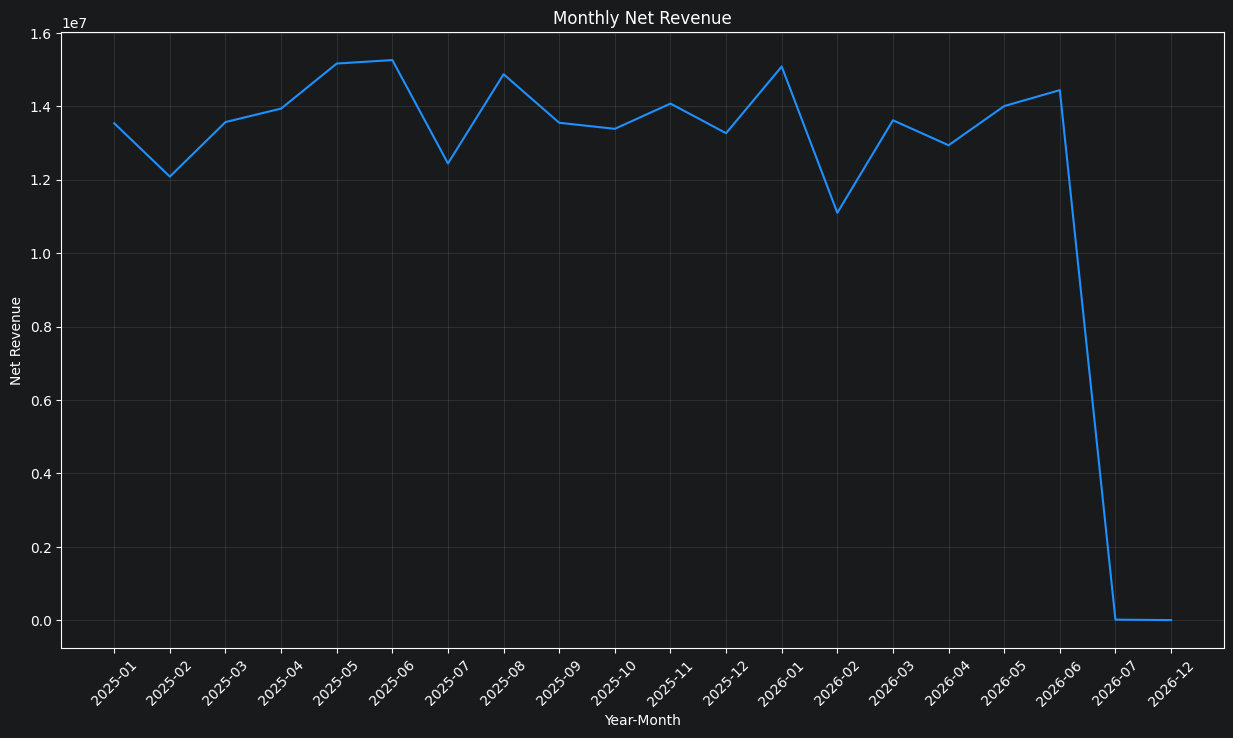

In [340]:
#Visualizing Monthly Revenue
plt.figure(figsize=(15,8))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, color = "dodgerblue")
plt.xlabel("Year-Month")
plt.ylabel("Net Revenue")
plt.title("Monthly Net Revenue")
plt.xticks(rotation = 45)
plt.grid(alpha = 0.2)

plt.show()

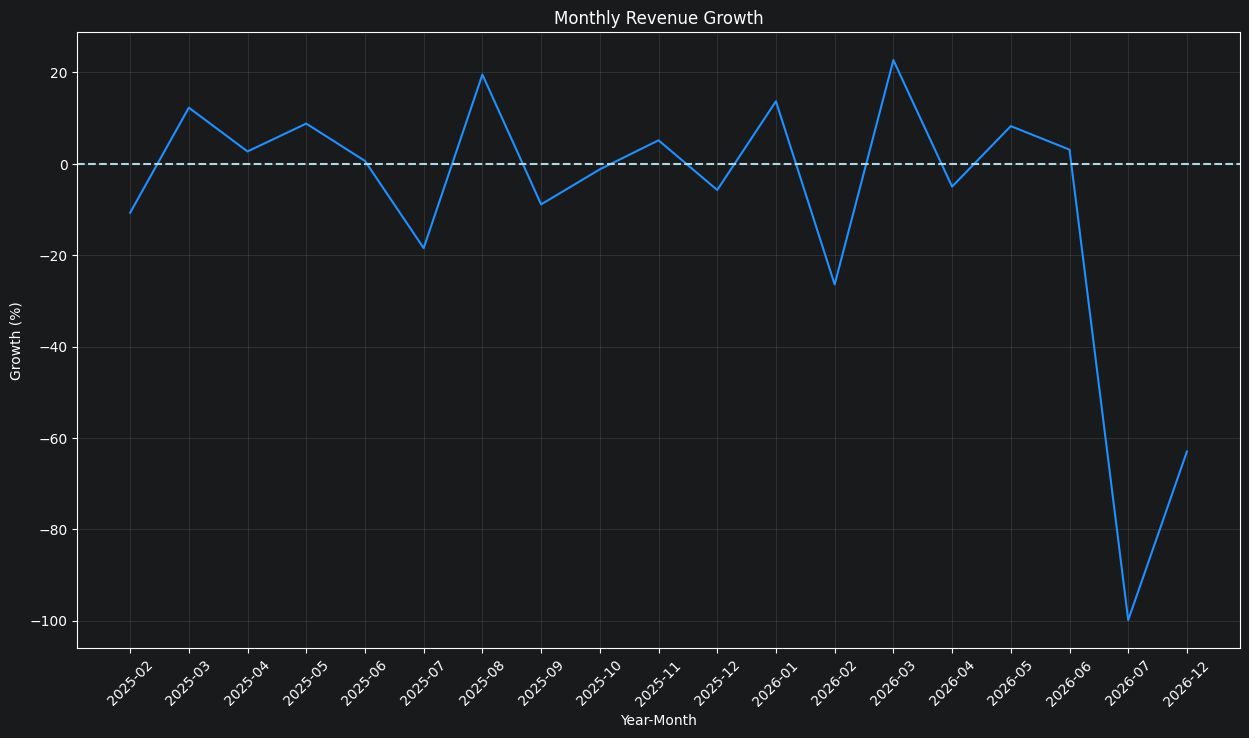

In [341]:
#Visualizing Monthly Growth
plt.figure(figsize=(15,8))
plt.plot(monthly_growth.index.astype(str), monthly_growth.values, color = "dodgerblue")
plt.xlabel("Year-Month")
plt.ylabel("Growth (%)")
plt.title("Monthly Revenue Growth")
plt.axhline(0, linestyle = '--', color="lightblue")
plt.xticks(rotation = 45)
plt.grid(alpha = 0.2)

plt.show()

In [342]:
df.dtypes

Order_ID                   object
Customer_ID                object
Date               datetime64[ns]
City                       object
Category                   object
Product                    object
Price                       int64
Quantity                    int64
Discount                  float64
Payment                    object
Order_Status               object
Revenue                     int64
Discount_amount           float64
Net_Revenue               float64
Year_Month              period[M]
dtype: object

In [343]:
# Finding Revenue by Payment Method

payment_wise_net_revenue = df.groupby("Payment")["Net_Revenue"].sum()
payment_wise_net_revenue = payment_wise_net_revenue.sort_values(ascending = False)
payment_wise_net_revenue # UPI is contributing to the most revenue

Payment
UPI                 98816426.5
Credit Card         49157132.5
Debit Card          38628823.5
Cash on Delivery    24179877.5
Net Banking         16753560.0
Wallet              16663484.0
Name: Net_Revenue, dtype: float64

In [344]:
payment_wise_net_revenue = payment_wise_net_revenue.to_frame(name="Net_Revenue")
payment_wise_net_revenue["Revenue_%"] = (payment_wise_net_revenue["Net_Revenue"] / payment_wise_net_revenue["Net_Revenue"].sum()) * 100

payment_wise_net_revenue["Revenue_%"] = round(payment_wise_net_revenue["Revenue_%"], 2)

In [345]:
print(payment_wise_net_revenue)
payment_wise_net_revenue["Revenue_%"].sum()

                  Net_Revenue  Revenue_%
Payment                                 
UPI                98816426.5      40.47
Credit Card        49157132.5      20.13
Debit Card         38628823.5      15.82
Cash on Delivery   24179877.5       9.90
Net Banking        16753560.0       6.86
Wallet             16663484.0       6.82


np.float64(100.0)

In [346]:
# Calculating the number of orders for each payment method.

payment_usage = df.groupby("Payment")["Order_ID"].nunique()
payment_usage.sort_values(ascending = False) # From this the UPI is both the most-used payment method and the highest-revenue payment method.


Payment
UPI                 6008
Credit Card         2939
Debit Card          2338
Cash on Delivery    1460
Wallet              1071
Net Banking         1034
Name: Order_ID, dtype: int64

In [347]:
# Payment Average Order Value
payment_usage = payment_usage.to_frame(name="Usage")

payment_data = pd.concat([payment_wise_net_revenue, payment_usage], axis = 1)
print(payment_data)

                  Net_Revenue  Revenue_%  Usage
Payment                                        
UPI                98816426.5      40.47   6008
Credit Card        49157132.5      20.13   2939
Debit Card         38628823.5      15.82   2338
Cash on Delivery   24179877.5       9.90   1460
Net Banking        16753560.0       6.86   1034
Wallet             16663484.0       6.82   1071


In [348]:
#Average order value by payment method (payment-wise)
payment_aov = df.groupby("Payment").agg(
    Total_Revenue = ("Net_Revenue", "sum"),
    Total_Orders = ("Order_ID", "nunique")
)

print(payment_aov)

                  Total_Revenue  Total_Orders
Payment                                      
Cash on Delivery     24179877.5          1460
Credit Card          49157132.5          2939
Debit Card           38628823.5          2338
Net Banking          16753560.0          1034
UPI                  98816426.5          6008
Wallet               16663484.0          1071


In [349]:
payment_aov["AOV"] = (
    payment_aov["Total_Revenue"] / payment_aov["Total_Orders"]
).round(2)

print(payment_aov)

                  Total_Revenue  Total_Orders       AOV
Payment                                                
Cash on Delivery     24179877.5          1460  16561.56
Credit Card          49157132.5          2939  16725.80
Debit Card           38628823.5          2338  16522.17
Net Banking          16753560.0          1034  16202.67
UPI                  98816426.5          6008  16447.47
Wallet               16663484.0          1071  15558.81


In [350]:
print(payment_wise_net_revenue)
print(payment_usage)
print(payment_aov)

                  Net_Revenue  Revenue_%
Payment                                 
UPI                98816426.5      40.47
Credit Card        49157132.5      20.13
Debit Card         38628823.5      15.82
Cash on Delivery   24179877.5       9.90
Net Banking        16753560.0       6.86
Wallet             16663484.0       6.82
                  Usage
Payment                
Cash on Delivery   1460
Credit Card        2939
Debit Card         2338
Net Banking        1034
UPI                6008
Wallet             1071
                  Total_Revenue  Total_Orders       AOV
Payment                                                
Cash on Delivery     24179877.5          1460  16561.56
Credit Card          49157132.5          2939  16725.80
Debit Card           38628823.5          2338  16522.17
Net Banking          16753560.0          1034  16202.67
UPI                  98816426.5          6008  16447.47
Wallet               16663484.0          1071  15558.81


In [351]:
# Order Status Analysis

order_status = df.groupby("Order_Status")["Order_ID"].nunique()
order_status = order_status.sort_values(ascending = False)
print(order_status)

Order_Status
Delivered    8582
Cancelled    2163
Returned     2148
Shipped      2077
Name: Order_ID, dtype: int64


In [352]:
order_status = order_status.to_frame(name = "Status_Count")
order_status["Status_Count(%)"] = (order_status["Status_Count"] / order_status["Status_Count"].sum()) * 100

order_status = order_status.round(2)

In [353]:
order_status

,Status_Count,Status_Count(%)
Order_Status,,
Delivered,8582,57.33
Cancelled,2163,14.45
Returned,2148,14.35
Shipped,2077,13.87


In [354]:
completion_rate = (order_status.loc[("Delivered", "Status_Count")] / order_status["Status_Count"].sum()) * 100

completion_rate = completion_rate.round(2)
completion_rate

np.float64(57.33)

In [355]:
cancellation_rate = (order_status["Status_Count"]["Cancelled"] / order_status["Status_Count"].sum()) * 100

cancellation_rate = cancellation_rate.round(2)
cancellation_rate

np.float64(14.45)

In [356]:
return_rate = (order_status["Status_Count"]["Returned"] / order_status["Status_Count"].sum()) * 100

return_rate = return_rate.round(2)
return_rate

np.float64(14.35)

In [357]:
delivered_revenue = df[df["Order_Status"] == "Delivered"]["Net_Revenue"].sum()

delivered_revenue

np.float64(144752567.0)

In [358]:
delivered_revenue_pct = (
    delivered_revenue / df["Net_Revenue"].sum()
) * 100

delivered_revenue_pct = round(delivered_revenue_pct, 2)

delivered_revenue_pct

np.float64(58.77)

In [359]:
# Calculating AOV for delivered_orders

delivered_orders = df[df["Order_Status"] == "Delivered"]["Order_ID"].nunique()

delivered_aov = delivered_revenue / delivered_orders
delivered_aov = round(delivered_aov, 2)

delivered_aov

np.float64(16867.0)

In [360]:
# Comparing the Overall Aov with Delivered Aov

print("Overall AOV:", aov)
print("Delivered AOV:", delivered_aov)
print("Difference:", round(delivered_aov - aov, 2))

Overall AOV: 16454.27
Delivered AOV: 16867.0
Difference: 412.73


In [361]:
# Calculate the percentage difference

aov_difference_pct = (
    (delivered_aov - aov) / aov
) * 100

aov_difference_pct = round(aov_difference_pct, 2)

aov_difference_pct # Delivered orders have a slightly higher average order value than the overall order population

np.float64(2.51)

In [362]:
# KPI (Key Performance Indicator)

sales_kpis = {
    "Total Customers": total_customers,
    "Total Orders": total_orders,
    "Overall AOV": aov,
    "Delivered Revenue": delivered_revenue,
    "Delivered Revenue %": delivered_revenue_pct,
    "Completion Rate": completion_rate,
    "Cancellation Rate": cancellation_rate,
    "Return Rate": return_rate,
    "Delivered AOV": delivered_aov
}

sales_kpis

{'Total Customers': 2494,
 'Total Orders': 14970,
 'Overall AOV': np.float64(16454.27),
 'Delivered Revenue': np.float64(144752567.0),
 'Delivered Revenue %': np.float64(58.77),
 'Completion Rate': np.float64(57.33),
 'Cancellation Rate': np.float64(14.45),
 'Return Rate': np.float64(14.35),
 'Delivered AOV': np.float64(16867.0)}

In [363]:
# =================================================================
# Customer Analysis

In [364]:
customer_orders = df.groupby("Customer_ID")["Order_ID"].nunique()
customer_orders

Customer_ID
C00001     3
C00002     5
C00003     7
C00004     4
C00005     5
          ..
C02496     4
C02497     4
C02498     7
C02499    11
C02500     6
Name: Order_ID, Length: 2494, dtype: int64

In [365]:
one_time_customers = (customer_orders == 1).sum()
repeat_customers = (customer_orders > 1).sum()

print("One-time customers:", one_time_customers)
print("Repeat customers:", repeat_customers)

One-time customers: 37
Repeat customers: 2457


In [366]:
repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

repeat_customer_rate = round(repeat_customer_rate, 2)

repeat_customer_rate

np.float64(98.52)

In [367]:
repeat_customer_ids = customer_orders[customer_orders > 1].index

In [368]:
repeat_customer_revenue = df[
    df["Customer_ID"].isin(repeat_customer_ids)
]["Net_Revenue"].sum()

repeat_customer_revenue

np.float64(245847304.0)

In [369]:
repeat_customer_revenue_pct = (
    repeat_customer_revenue / df["Net_Revenue"].sum()
) * 100

repeat_customer_revenue_pct = round(repeat_customer_revenue_pct, 2)

repeat_customer_revenue_pct

np.float64(99.81)

In [370]:
revenue_per_customer = (
    df["Net_Revenue"].sum() / total_customers
)

revenue_per_customer = round(revenue_per_customer, 2)

revenue_per_customer

np.float64(98765.2)

In [371]:
customer_revenue = (
    df.groupby("Customer_ID")["Net_Revenue"].sum().sort_values(ascending=False)
)

customer_revenue.head(10)

Customer_ID
C01190    476745.0
C00504    471247.0
C00712    450588.0
C01760    437664.5
C01479    375198.0
C00888    374677.5
C01954    366770.0
C01893    360857.0
C01317    355587.5
C00982    354096.0
Name: Net_Revenue, dtype: float64

In [372]:
customer_summary = (
    df.groupby("Customer_ID").agg(
        Total_Revenue = ("Net_Revenue", "sum"),
        Total_Orders = ("Order_ID", "nunique")
    ).sort_values("Total_Revenue", ascending=False)
)

customer_summary.head(10)


,Total_Revenue,Total_Orders
Customer_ID,,
C01190,476745.0,10
C00504,471247.0,11
C00712,450588.0,14
C01760,437664.5,13
C01479,375198.0,8
C00888,374677.5,9
C01954,366770.0,8
C01893,360857.0,11
C01317,355587.5,9


In [373]:
customer_summary["AOV"] = (
    customer_summary["Total_Revenue"] / customer_summary["Total_Orders"]
).round(2)

customer_summary.head(10)

,Total_Revenue,Total_Orders,AOV
Customer_ID,,,
C01190,476745.0,10,47674.50
C00504,471247.0,11,42840.64
C00712,450588.0,14,32184.86
C01760,437664.5,13,33666.50
C01479,375198.0,8,46899.75
C00888,374677.5,9,41630.83
C01954,366770.0,8,45846.25
C01893,360857.0,11,32805.18
C01317,355587.5,9,39509.72


In [374]:
top_aov_customers = customer_summary.sort_values(
    "AOV", ascending=False
).head(10)

top_aov_customers

,Total_Revenue,Total_Orders,AOV
Customer_ID,,,
C00295,280005.0,3,93335.00
C00237,185156.0,2,92578.00
C01875,344905.0,5,68981.00
C00536,296069.0,5,59213.80
C00982,354096.0,6,59016.00
C01348,294034.0,5,58806.80
C02391,176030.0,3,58676.67
C00999,110861.0,2,55430.50
C00574,109599.0,2,54799.50


In [375]:
customer_orders.describe()

count    2494.000000
mean        6.002406
std         2.331010
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        15.000000
Name: Order_ID, dtype: float64

In [376]:
customer_orders.value_counts().sort_index()

Order_ID
1      37
2      78
3     223
4     360
5     423
6     387
7     358
8     257
9     188
10     97
11     44
12     28
13     11
14      1
15      2
Name: count, dtype: int64

In [377]:
# Calculate the average number of orders placed by each customer:

avg_orders_per_customer = customer_orders.mean()
avg_orders_per_customer = round(avg_orders_per_customer, 2)

avg_orders_per_customer

np.float64(6.0)

In [378]:
# Calculating how much of the business's revenue comes from the top 10 customers.

top_10_revenue = customer_summary.head(10)["Total_Revenue"].sum()
top_10_revenue_pct = (
    top_10_revenue / df["Net_Revenue"].sum()
) * 100

top_10_revenue_pct = round(top_10_revenue_pct, 2)

top_10_revenue_pct

np.float64(1.63)

In [379]:
# classifying customers based on their total revenue.

customer_revenue.quantile([0.25, 0.50, 0.75])

0.25     46657.125
0.50     82575.250
0.75    132977.875
Name: Net_Revenue, dtype: float64

In [380]:
q1 = customer_revenue.quantile(0.25)
q3 = customer_revenue.quantile(0.75)

customer_segment = pd.cut(
    customer_revenue,
    bins=[-float("inf"), q1, q3, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_segment

Customer_ID
C01190    High Value
C00504    High Value
C00712    High Value
C01760    High Value
C01479    High Value
             ...    
C00632     Low Value
C01205     Low Value
C01950     Low Value
C00814     Low Value
C00523     Low Value
Name: Net_Revenue, Length: 2494, dtype: category
Categories (3, object): ['Low Value' < 'Medium Value' < 'High Value']

In [381]:
segment_revenue = (
    df.assign(Customer_Segment=df["Customer_ID"].map(customer_segment))
      .groupby("Customer_Segment", observed=True)["Net_Revenue"]
      .sum()
      .sort_values(ascending=False)
)

segment_revenue

Customer_Segment
High Value      122173462.0
Medium Value    106665919.5
Low Value        17481025.0
Name: Net_Revenue, dtype: float64

In [382]:
segment_revenue_pct = (
    segment_revenue / segment_revenue.sum()
) * 100

segment_revenue_pct = segment_revenue_pct.round(2)

segment_revenue_pct

Customer_Segment
High Value      49.6
Medium Value    43.3
Low Value        7.1
Name: Net_Revenue, dtype: float64

In [383]:
# finding whether customers who order more frequently also generate more revenue.

customer_summary["Total_Orders"].corr(
    customer_summary["Total_Revenue"]
)

np.float64(0.5815524478268166)

In [384]:
# finding customers who order more frequently also tend to have higher or lower AOV.
customer_summary["Total_Orders"].corr(
    customer_summary["AOV"]
)

np.float64(0.036217822675339205)

In [385]:
customer_revenue_sorted = customer_revenue.sort_values(ascending=False)

cumulative_revenue_pct = (
    customer_revenue_sorted.cumsum()
    / customer_revenue_sorted.sum()
) * 100

cumulative_revenue_pct.head(10)

Customer_ID
C01190    0.193547
C00504    0.384861
C00712    0.567789
C01760    0.745470
C01479    0.897791
C00888    1.049901
C01954    1.198800
C01893    1.345299
C01317    1.489659
C00982    1.633413
Name: Net_Revenue, dtype: float64

In [386]:
customers_for_80 = (
    cumulative_revenue_pct <= 80
).sum()

customers_for_80

np.int64(1351)

In [387]:
customers_to_80 = (cumulative_revenue_pct >= 80).idxmax()
customers_to_80

'C00664'

In [388]:
customers_to_80 = (cumulative_revenue_pct >= 80).to_numpy().argmax() + 1
customers_to_80

np.int64(1352)

In [389]:
# Product & Category Analysis
#Top 10 products by revenue

product_revenue = (
    df.groupby("Product")["Net_Revenue"]
      .sum()
      .sort_values(ascending=False)
)

product_revenue.head(10)

Product
USB-C Hub              20706059.5
Wireless Earbuds       20041737.0
Headphones             19966916.0
Gaming Mouse           19844533.0
Mechanical Keyboard    19637546.0
Smartwatch             18833817.5
Power Bank             18815593.0
Bluetooth Speaker      16881640.5
Coffee Mug              7200970.5
Mixer Grinder           7046176.5
Name: Net_Revenue, dtype: float64

In [390]:
#Calculating how many units of each product were sold:

product_quantity = (
    df.groupby("Product")["Quantity"].sum()
    .sort_values(ascending = False)
)

product_quantity.head()

Product
USB-C Hub              1265
Wireless Earbuds       1256
Headphones             1246
Mechanical Keyboard    1202
Power Bank             1194
Name: Quantity, dtype: int64

In [391]:
#calculate the average revenue generated per order for each product.

product_summary = (
    df.groupby("Product")
      .agg(
          Total_Revenue=("Net_Revenue", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
)

product_summary["AOV"] = (
    product_summary["Total_Revenue"] /
    product_summary["Total_Orders"]
).round(2)

product_summary.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

,Total_Revenue,Total_Orders,Total_Quantity,AOV
Product,,,,
USB-C Hub,20706059.5,584,1265,35455.58
Wireless Earbuds,20041737.0,575,1256,34855.19
Headphones,19966916.0,577,1246,34604.71
Gaming Mouse,19844533.0,542,1171,36613.53
Mechanical Keyboard,19637546.0,543,1202,36164.91
Smartwatch,18833817.5,552,1147,34119.23
Power Bank,18815593.0,562,1194,33479.70
Bluetooth Speaker,16881640.5,514,1101,32843.66
Coffee Mug,7200970.5,379,831,18999.92


In [392]:
product_summary["Avg_Price_Per_Unit"] = (
    product_summary["Total_Revenue"] /
    product_summary["Total_Quantity"]
).round(2)

product_summary.sort_values(
    "Avg_Price_Per_Unit",
    ascending=False
)


,Total_Revenue,Total_Orders,Total_Quantity,AOV,Avg_Price_Per_Unit
Product,,,,,
Gaming Mouse,19844533.0,542,1171,36613.53,16946.65
Smartwatch,18833817.5,552,1147,34119.23,16420.07
USB-C Hub,20706059.5,584,1265,35455.58,16368.43
Mechanical Keyboard,19637546.0,543,1202,36164.91,16337.39
Headphones,19966916.0,577,1246,34604.71,16024.81
Wireless Earbuds,20041737.0,575,1256,34855.19,15956.80
Power Bank,18815593.0,562,1194,33479.70,15758.45
Bluetooth Speaker,16881640.5,514,1101,32843.66,15333.01
Coffee Mug,7200970.5,379,831,18999.92,8665.43


In [393]:
product_summary["Revenue_%"] = (
    product_summary["Total_Revenue"] /
    product_summary["Total_Revenue"].sum()
) * 100

product_summary["Revenue_%"] = product_summary["Revenue_%"].round(2)

product_summary.sort_values(
    "Revenue_%",
    ascending=False
).head(10)


,Total_Revenue,Total_Orders,Total_Quantity,AOV,Avg_Price_Per_Unit,Revenue_%
Product,,,,,,
USB-C Hub,20706059.5,584,1265,35455.58,16368.43,8.41
Wireless Earbuds,20041737.0,575,1256,34855.19,15956.80,8.14
Headphones,19966916.0,577,1246,34604.71,16024.81,8.11
Gaming Mouse,19844533.0,542,1171,36613.53,16946.65,8.06
Mechanical Keyboard,19637546.0,543,1202,36164.91,16337.39,7.97
Smartwatch,18833817.5,552,1147,34119.23,16420.07,7.65
Power Bank,18815593.0,562,1194,33479.70,15758.45,7.64
Bluetooth Speaker,16881640.5,514,1101,32843.66,15333.01,6.85
Coffee Mug,7200970.5,379,831,18999.92,8665.43,2.92


In [394]:
category_summary = (
    df.groupby("Category")
      .agg(
          Total_Revenue=("Net_Revenue", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
)

category_summary["AOV"] = (
    category_summary["Total_Revenue"] /
    category_summary["Total_Orders"]
).round(2)

category_summary["Revenue_%"] = (
    category_summary["Total_Revenue"] /
    category_summary["Total_Revenue"].sum()
) * 100

category_summary["Revenue_%"] = category_summary["Revenue_%"].round(2)

category_summary.sort_values(
    "Total_Revenue",
    ascending=False
)

,Total_Revenue,Total_Orders,Total_Quantity,AOV,Revenue_%
Category,,,,,
Electronics,155035748.5,4502,9693,34437.08,62.94
Home & Kitchen,53099666.0,2931,6382,18116.57,21.56
Clothing,24847861.5,3623,7967,6858.37,10.09
Beauty,9932247.5,2171,4715,4574.96,4.03
Books,3404883.0,1743,3822,1953.46,1.38


In [395]:
category_summary["Order_%"] = (
    category_summary["Total_Orders"] /
    category_summary["Total_Orders"].sum()
) * 100

category_summary["Order_%"] = category_summary["Order_%"].round(2)

category_summary["Revenue_vs_Order_Gap"] = (
    category_summary["Revenue_%"] -
    category_summary["Order_%"]
).round(2)

category_summary.sort_values(
    "Revenue_vs_Order_Gap",
    ascending=False
)

,Total_Revenue,Total_Orders,Total_Quantity,AOV,Revenue_%,Order_%,Revenue_vs_Order_Gap
Category,,,,,,,
Electronics,155035748.5,4502,9693,34437.08,62.94,30.07,32.87
Home & Kitchen,53099666.0,2931,6382,18116.57,21.56,19.58,1.98
Books,3404883.0,1743,3822,1953.46,1.38,11.64,-10.26
Beauty,9932247.5,2171,4715,4574.96,4.03,14.50,-10.47
Clothing,24847861.5,3623,7967,6858.37,10.09,24.20,-14.11


In [396]:
category_summary["Revenue_Per_Unit"] = (
    category_summary["Total_Revenue"] /
    category_summary["Total_Quantity"]
).round(2)

category_summary.sort_values(
    "Revenue_Per_Unit",
    ascending=False
)[["Revenue_Per_Unit", "AOV", "Total_Quantity", "Total_Revenue"]]

,Revenue_Per_Unit,AOV,Total_Quantity,Total_Revenue
Category,,,,
Electronics,15994.61,34437.08,9693,155035748.5
Home & Kitchen,8320.22,18116.57,6382,53099666.0
Clothing,3118.85,6858.37,7967,24847861.5
Beauty,2106.52,4574.96,4715,9932247.5
Books,890.86,1953.46,3822,3404883.0


In [397]:
product_summary.sort_values(
    "Total_Revenue",
    ascending=False
)[[
    "Total_Revenue",
    "Total_Quantity",
    "AOV",
    "Avg_Price_Per_Unit",
    "Revenue_%"
]].head(10)

,Total_Revenue,Total_Quantity,AOV,Avg_Price_Per_Unit,Revenue_%
Product,,,,,
USB-C Hub,20706059.5,1265,35455.58,16368.43,8.41
Wireless Earbuds,20041737.0,1256,34855.19,15956.80,8.14
Headphones,19966916.0,1246,34604.71,16024.81,8.11
Gaming Mouse,19844533.0,1171,36613.53,16946.65,8.06
Mechanical Keyboard,19637546.0,1202,36164.91,16337.39,7.97
Smartwatch,18833817.5,1147,34119.23,16420.07,7.65
Power Bank,18815593.0,1194,33479.70,15758.45,7.64
Bluetooth Speaker,16881640.5,1101,32843.66,15333.01,6.85
Coffee Mug,7200970.5,831,18999.92,8665.43,2.92


In [398]:
product_summary.sort_values(
    "Total_Revenue",
    ascending=False
)[[
    "Total_Revenue",
    "Total_Quantity",
    "AOV",
    "Avg_Price_Per_Unit",
    "Revenue_%"
]].head(10)

,Total_Revenue,Total_Quantity,AOV,Avg_Price_Per_Unit,Revenue_%
Product,,,,,
USB-C Hub,20706059.5,1265,35455.58,16368.43,8.41
Wireless Earbuds,20041737.0,1256,34855.19,15956.80,8.14
Headphones,19966916.0,1246,34604.71,16024.81,8.11
Gaming Mouse,19844533.0,1171,36613.53,16946.65,8.06
Mechanical Keyboard,19637546.0,1202,36164.91,16337.39,7.97
Smartwatch,18833817.5,1147,34119.23,16420.07,7.65
Power Bank,18815593.0,1194,33479.70,15758.45,7.64
Bluetooth Speaker,16881640.5,1101,32843.66,15333.01,6.85
Coffee Mug,7200970.5,831,18999.92,8665.43,2.92


In [399]:
# Time-Based Analysis
df.dtypes
# Which months generated the most and least revenue?

Order_ID                   object
Customer_ID                object
Date               datetime64[ns]
City                       object
Category                   object
Product                    object
Price                       int64
Quantity                    int64
Discount                  float64
Payment                    object
Order_Status               object
Revenue                     int64
Discount_amount           float64
Net_Revenue               float64
Year_Month              period[M]
dtype: object

In [400]:
monthly_revenue.sort_values(ascending=False)

Year_Month
2025-06    15256484.5
2025-05    15161816.0
2026-01    15080442.0
2025-08    14870944.5
2026-06    14437884.5
2025-11    14071901.5
2026-05    14004028.0
2025-04    13935153.5
2026-03    13616897.5
2025-03    13568572.0
2025-09    13548990.5
2025-01    13534764.5
2025-10    13384289.5
2025-12    13265199.5
2026-04    12936864.5
2025-07    12440885.0
2025-02    12083499.0
2026-02    11097381.0
2026-07       17813.0
2026-12        6596.0
Freq: M, Name: Net_Revenue, dtype: float64

In [401]:
monthly_growth.sort_values()


Year_Month
2026-07   -99.876623
2026-12   -62.970864
2026-02   -26.412097
2025-07   -18.455100
2025-02   -10.722503
2025-09    -8.889509
2025-12    -5.732715
2026-04    -4.994038
2025-10    -1.215596
2025-06     0.624388
2025-04     2.701696
2026-06     3.098084
2025-11     5.137456
2026-05     8.249012
2025-05     8.802648
2025-03    12.290091
2026-01    13.684246
2025-08    19.532851
2026-03    22.703704
2025-01          NaN
Freq: M, Name: Net_Revenue, dtype: float64

In [402]:
# Investigating July 2026, as why there is a sudden drop in revenue

july_2026 = df[
    (df["Date"].dt.year == 2026) &
    (df["Date"].dt.month == 7)
]

july_2026.shape

(2, 15)

In [403]:
july_2026["Order_Status"].value_counts()

Order_Status
Shipped      1
Delivered    1
Name: count, dtype: int64

In [404]:
july_2026[["Order_ID", "Customer_ID", "Quantity", "Net_Revenue", "Order_Status"]].head()

,Order_ID,Customer_ID,Quantity,Net_Revenue,Order_Status
4161,ORD2025001502,C02429,5,17255.0,Shipped
5809,ORD2025001005,C01169,1,558.0,Delivered


In [405]:
# Discount Analysis

df["Discount"].describe()

count    15045.000000
mean         9.022599
std          8.071908
min          0.000000
25%          0.000000
50%         10.000000
75%         15.000000
max         30.000000
Name: Discount, dtype: float64

In [406]:
df["Discount"].value_counts().sort_index()

Discount
0.0     4288
5.0     2945
10.0    3124
15.0    2167
20.0    1440
25.0     791
30.0     290
Name: count, dtype: int64

In [407]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Total_Revenue=("Net_Revenue", "sum"),
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum")
      )
)

discount_analysis["AOV"] = (
    discount_analysis["Total_Revenue"] /
    discount_analysis["Total_Orders"]
).round(2)

discount_analysis["Revenue_Per_Unit"] = (
    discount_analysis["Total_Revenue"] /
    discount_analysis["Total_Quantity"]
).round(2)

discount_analysis

,Total_Revenue,Total_Orders,Total_Quantity,AOV,Revenue_Per_Unit
Discount,,,,,
0.0,77312010.0,4261,9282,18144.10,8329.24
5.0,51674148.0,2931,6248,17630.21,8270.51
10.0,50985036.0,3112,6873,16383.37,7418.16
15.0,31764100.5,2156,4663,14732.89,6811.95
20.0,20100248.0,1433,3174,14026.69,6332.78
25.0,10848945.0,788,1738,13767.70,6242.20
30.0,3635919.0,289,601,12581.03,6049.78


In [408]:
# Finding whether customers buy more units when they receive bigger discounts.

discount_analysis["Avg_Quantity_Per_Order"] = (
    discount_analysis["Total_Quantity"] /
    discount_analysis["Total_Orders"]
).round(2)

discount_analysis[
    ["Total_Orders", "Total_Quantity", "Avg_Quantity_Per_Order", "AOV"]
]

,Total_Orders,Total_Quantity,Avg_Quantity_Per_Order,AOV
Discount,,,,
0.0,4261,9282,2.18,18144.10
5.0,2931,6248,2.13,17630.21
10.0,3112,6873,2.21,16383.37
15.0,2156,4663,2.16,14732.89
20.0,1433,3174,2.21,14026.69
25.0,788,1738,2.21,13767.70
30.0,289,601,2.08,12581.03


In [409]:
df[["Discount", "Net_Revenue", "Quantity"]].corr()

,Discount,Net_Revenue,Quantity
Discount,1.000000,-0.070277,0.005685
Net_Revenue,-0.070277,1.000000,0.432438
Quantity,0.005685,0.432438,1.000000


In [410]:
# Statistical / Outlier Analysis

Q1 = df["Net_Revenue"].quantile(0.25)
Q3 = df["Net_Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_bound, upper_bound

(np.float64(2816.0),
 np.float64(20475.0),
 np.float64(17659.0),
 np.float64(-23672.5),
 np.float64(46963.5))

In [411]:
outliers = df[df["Net_Revenue"] > upper_bound]

outliers.shape

(1313, 15)

In [412]:
outliers["Net_Revenue"].sort_values(ascending=False).head(10)

2070     208740.0
13328    197820.0
12204    192717.0
12255    188568.0
14941    187872.0
3039     186000.0
10889    185535.0
13228    184734.0
11897    184200.0
13752    179928.0
Name: Net_Revenue, dtype: float64

In [413]:
outliers[
    ["Order_ID", "Customer_ID", "Product", "Quantity",
     "Price", "Discount", "Net_Revenue", "Order_Status"]
].sort_values("Net_Revenue", ascending=False).head(10)

,Order_ID,Customer_ID,Product,Quantity,Price,Discount,Net_Revenue,Order_Status
2070,ORD2025013849,C00712,Gaming Mouse,6,34790,0.0,208740.0,Delivered
13328,ORD2025012653,C00120,Gaming Mouse,6,32970,0.0,197820.0,Delivered
12204,ORD2025011872,C01961,Headphones,6,33810,5.0,192717.0,Delivered
12255,ORD2025001443,C01348,Smartwatch,6,34920,10.0,188568.0,Delivered
14941,ORD2025009688,C00137,Headphones,6,32960,5.0,187872.0,Delivered
3039,ORD2025011591,C01983,Gaming Mouse,6,31000,0.0,186000.0,Cancelled
10889,ORD2025001949,C00938,Gaming Mouse,6,32550,5.0,185535.0,Delivered
13228,ORD2025002984,C01058,Mechanical Keyboard,6,34210,10.0,184734.0,Delivered
11897,ORD2025010449,C01994,Gaming Mouse,6,30700,0.0,184200.0,Delivered
13752,ORD2025008008,C02194,Mechanical Keyboard,6,33320,10.0,179928.0,Delivered


In [414]:
category_summary

,Total_Revenue,Total_Orders,Total_Quantity,AOV,Revenue_%,Order_%,Revenue_vs_Order_Gap,Revenue_Per_Unit
Category,,,,,,,,
Beauty,9932247.5,2171,4715,4574.96,4.03,14.50,-10.47,2106.52
Books,3404883.0,1743,3822,1953.46,1.38,11.64,-10.26,890.86
Clothing,24847861.5,3623,7967,6858.37,10.09,24.20,-14.11,3118.85
Electronics,155035748.5,4502,9693,34437.08,62.94,30.07,32.87,15994.61
Home & Kitchen,53099666.0,2931,6382,18116.57,21.56,19.58,1.98,8320.22


In [415]:
# Identifying the biggest revenue driver

df.groupby("Category")["Discount"].mean().sort_values(ascending=False)

Category
Clothing          9.335809
Books             9.074074
Electronics       8.997790
Beauty            8.851971
Home & Kitchen    8.769936
Name: Discount, dtype: float64

In [416]:
df.groupby("Category")["Quantity"].mean().sort_values(ascending=False)

Category
Clothing          2.191144
Books             2.177778
Home & Kitchen    2.165592
Beauty            2.160862
Electronics       2.142099
Name: Quantity, dtype: float64

In [417]:
df.groupby("Category")["Price"].mean().sort_values(ascending=False)


Category
Electronics       17540.512707
Home & Kitchen     9193.383101
Clothing           3467.296480
Beauty             2307.153987
Books               976.387464
Name: Price, dtype: float64

In [418]:
customer_orders.describe()

count    2494.000000
mean        6.002406
std         2.331010
min         1.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        15.000000
Name: Order_ID, dtype: float64

In [419]:
category_status = pd.crosstab(
    df["Category"],
    df["Order_Status"],
    normalize="index"
) * 100

category_status.round(2)

Order_Status,Cancelled,Delivered,Returned,Shipped
Category,,,,
Beauty,13.70,57.70,15.17,13.43
Books,14.07,56.81,15.27,13.85
Clothing,14.88,55.72,14.77,14.63
Electronics,14.56,58.48,13.57,13.39
Home & Kitchen,14.56,57.62,13.81,14.01


In [420]:
discount_status = pd.crosstab(
    df["Discount"],
    df["Order_Status"],
    normalize="index"
) * 100

discount_status.round(2)

Order_Status,Cancelled,Delivered,Returned,Shipped
Discount,,,,
0.0,14.79,57.18,14.13,13.90
5.0,14.77,57.56,13.58,14.09
10.0,13.38,57.78,15.01,13.83
15.0,15.60,57.87,14.07,12.46
20.0,14.10,57.08,14.37,14.44
25.0,14.29,54.61,16.06,15.04
30.0,11.72,57.24,14.83,16.21


In [421]:
product_status = pd.crosstab(
    df["Product"],
    df["Order_Status"],
    normalize="index"
) * 100

product_status.round(2)

Order_Status,Cancelled,Delivered,Returned,Shipped
Product,,,,
Air Fryer,14.83,58.43,12.21,14.53
Bedsheet,15.78,55.61,16.58,12.03
Bluetooth Speaker,12.98,57.75,16.28,12.98
Body Lotion,10.16,54.69,17.97,17.19
Business Management,16.25,56.25,15.00,12.50
Coffee Mug,15.30,58.84,11.35,14.51
Cookware Set,13.44,59.95,12.63,13.98
Data Analytics,18.26,58.45,14.16,9.13
Exam Guide,11.40,59.21,14.91,14.47


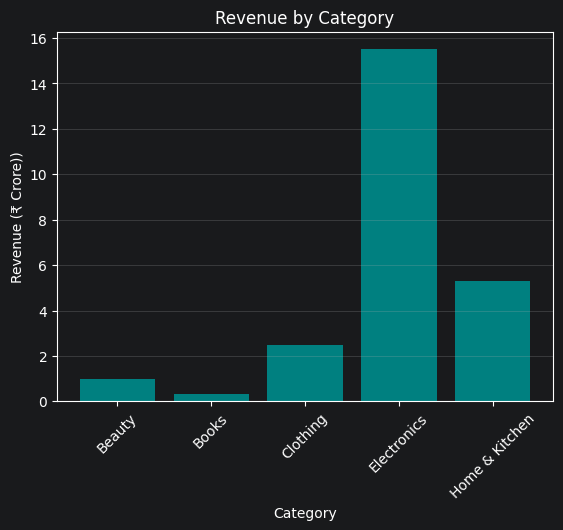

In [422]:
# ====================================================
# Visualizing Data

# Revenue by Category.

category_revenue = category_revenue.copy()

category_revenue["Revenue_Crore"] = (
    category_revenue["Net_Revenue"] / 10_000_000
)

plt.bar(
    category_revenue.index,
    category_revenue["Revenue_Crore"],
    color="teal")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹ Crore))")

plt.xticks(rotation = 45)
plt.grid(axis = 'y', alpha = 0.3)
plt.show()

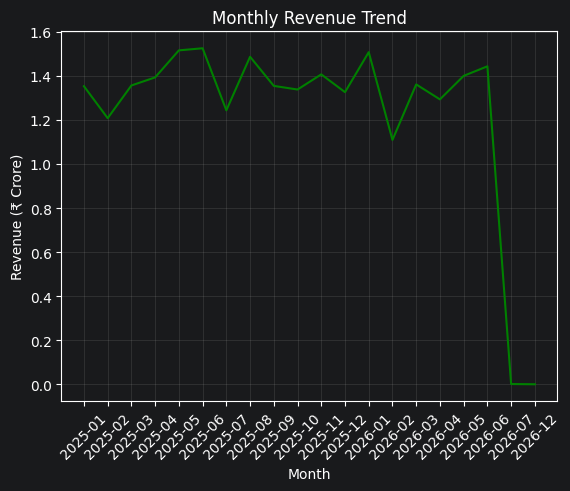

In [423]:
# Monthly Revenue Trend

monthly_revenue_crore = monthly_revenue / 10_000_000

plt.plot(
    monthly_revenue_crore.index.astype(str),
    monthly_revenue_crore,
    color="green"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Crore)")

plt.xticks(rotation = 45)
plt.grid(alpha=0.2)
plt.show()

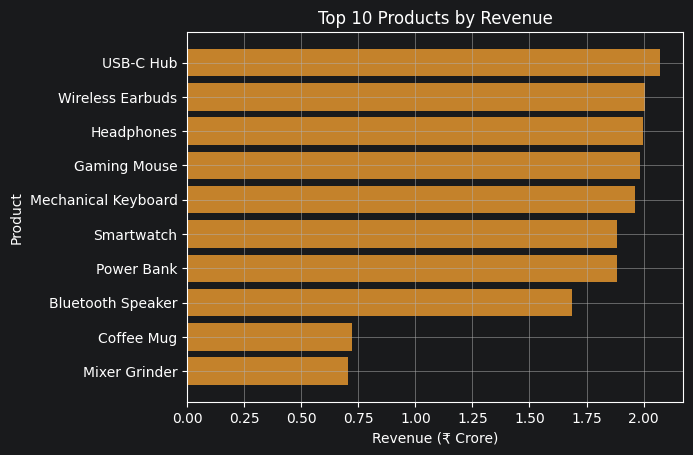

In [424]:
# Top 10 Products by Revenue

product_revenue_crores = product_revenue.head(10) / 10_000_000
plt.barh(
    product_revenue.head(10).index,
    product_revenue_crores,
    color = "#c4822b"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (₹ Crore)")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.grid(alpha=0.7)
plt.show()

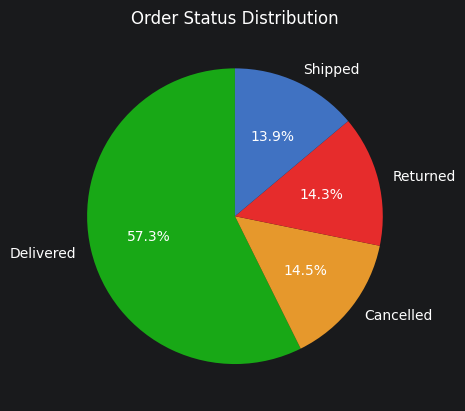

In [425]:
# Order Status Distribution

status_counts = df["Order_Status"].value_counts()

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=["#18a816", "#e6982c", "#e62c2c", "#4072c2"],
    startangle=90
)

plt.title("Order Status Distribution")
plt.show()

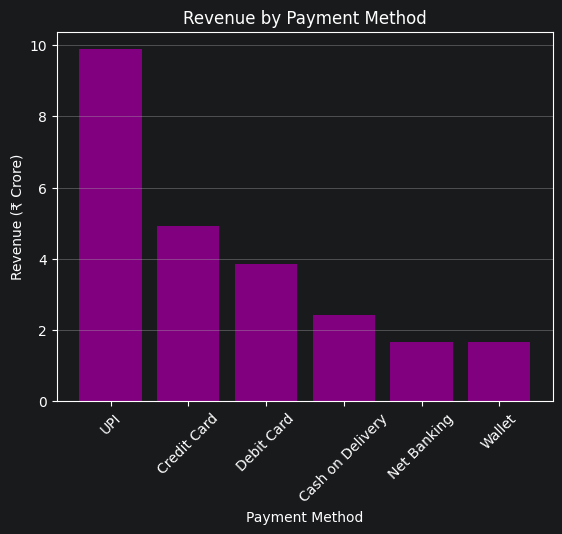

In [426]:
# Revenue by Payment Method

payment_data_revenue = payment_data["Net_Revenue"] / 10_000_000

plt.bar(payment_data.index,
        payment_data_revenue,
        color="purple")

plt.xlabel("Payment Method")
plt.ylabel("Revenue (₹ Crore)")
plt.title("Revenue by Payment Method")

plt.xticks(rotation = 45)
plt.grid(axis='y', alpha=0.5)
plt.show()

In [427]:
category_summary

,Total_Revenue,Total_Orders,Total_Quantity,AOV,Revenue_%,Order_%,Revenue_vs_Order_Gap,Revenue_Per_Unit
Category,,,,,,,,
Beauty,9932247.5,2171,4715,4574.96,4.03,14.50,-10.47,2106.52
Books,3404883.0,1743,3822,1953.46,1.38,11.64,-10.26,890.86
Clothing,24847861.5,3623,7967,6858.37,10.09,24.20,-14.11,3118.85
Electronics,155035748.5,4502,9693,34437.08,62.94,30.07,32.87,15994.61
Home & Kitchen,53099666.0,2931,6382,18116.57,21.56,19.58,1.98,8320.22


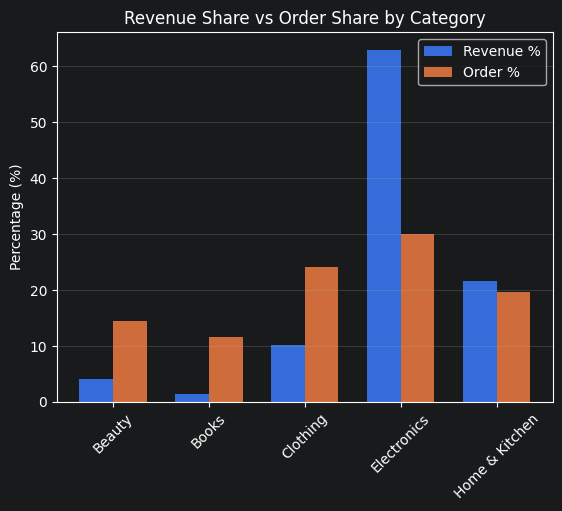

In [428]:
# Revenue Share vs Order Share

x = np.arange(len(category_summary.index))
width = 0.35

plt.bar(x - width/2, category_summary["Revenue_%"], width, label="Revenue %")

plt.bar(x + width/2, category_summary["Order_%"], width, label="Order %")

plt.ylabel('Percentage (%)')
plt.title('Revenue Share vs Order Share by Category')
plt.xticks(x, category_summary.index, rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

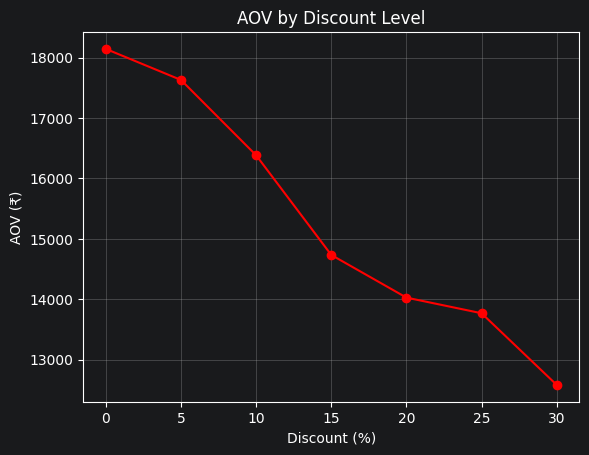

In [429]:
# Discount vs AOV

plt.plot(discount_analysis.index,
         discount_analysis["AOV"],
         marker = 'o',
         color="red")

plt.xlabel("Discount (%)")
plt.ylabel("AOV (₹)")
plt.title("AOV by Discount Level")

plt.grid(alpha=0.4)
plt.show()

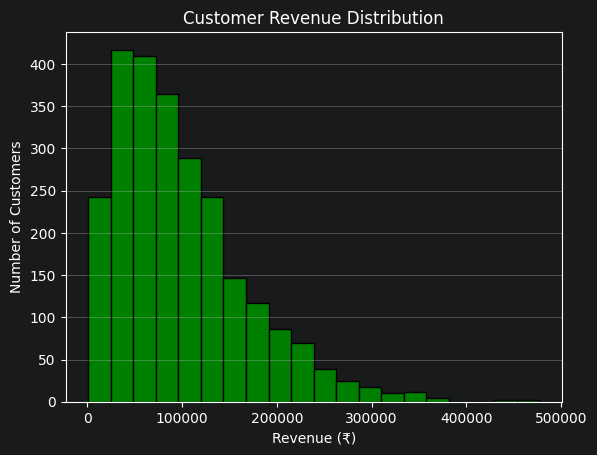

In [430]:
plt.hist(customer_revenue, bins=20, edgecolor="black", color= "green")
plt.xlabel("Revenue (₹)")
plt.ylabel("Number of Customers")
plt.title("Customer Revenue Distribution")

plt.grid(axis="y")
plt.show()

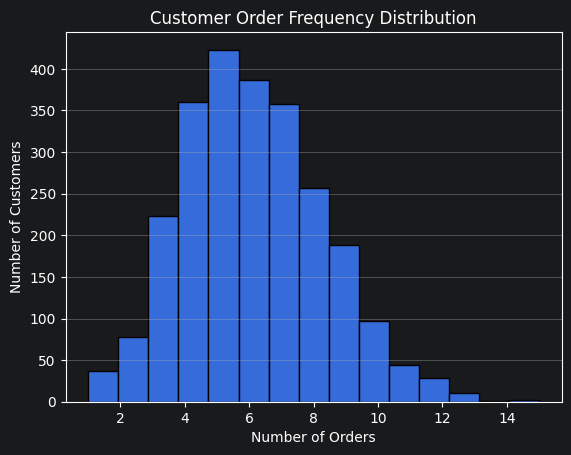

In [431]:
# Customer Orders Distribution

plt.hist(customer_summary["Total_Orders"], bins=15, edgecolor = "black")

plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Customer Order Frequency Distribution")

plt.grid(axis="y")
plt.show()

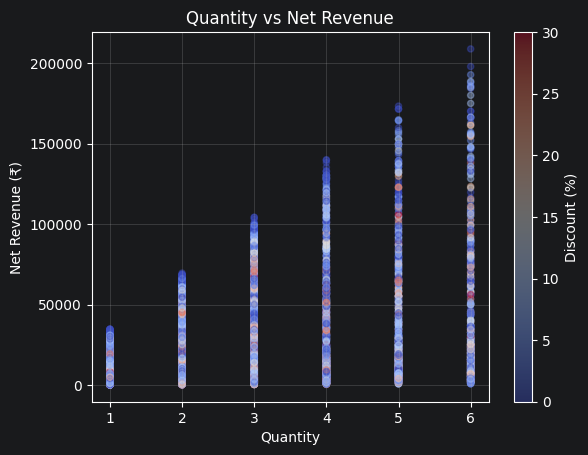

In [432]:
# Quantity vs Net Revenue

plt.scatter(
    df["Quantity"],
    df["Net_Revenue"],
    c=df["Discount"],
    cmap="coolwarm",
    alpha=0.4,
    s=20
)

plt.xlabel("Quantity")
plt.ylabel("Net Revenue (₹)")
plt.title("Quantity vs Net Revenue")
plt.colorbar(label="Discount (%)")
plt.grid(alpha=0.3)
plt.show()

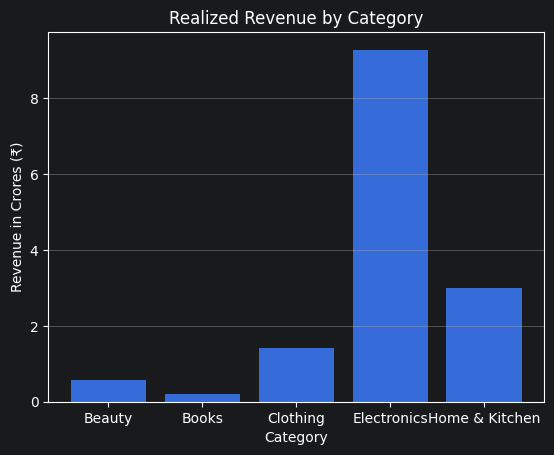

In [433]:
# Revenue Generated from just Delivered Orders

df["Realized_Revenue"] = np.where(
    df["Order_Status"] == "Delivered",
    df["Net_Revenue"],
    0
)

realized_revenue_category_wise = df.groupby("Category")["Realized_Revenue"].sum()

plt.bar(realized_revenue_category_wise.index,
        realized_revenue_category_wise / 10000000)

plt.xlabel("Category")
plt.ylabel("Revenue in Crores (₹)")
plt.title("Realized Revenue by Category")
plt.grid(axis = "y")
plt.show()

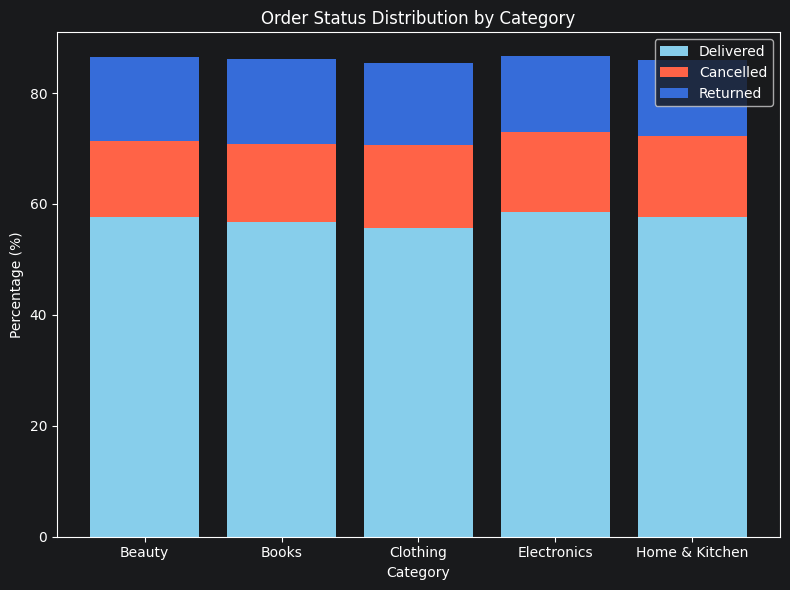

In [434]:
# Order Status Distribution by Category

order_status_per_category = pd.crosstab(
    df["Category"],
    df["Order_Status"],
    normalize="index"
) * 100

plt.figure(figsize=(8,6))

plt.bar(order_status_per_category.index,
        order_status_per_category["Delivered"],
        color="skyblue",
        label="Delivered")

plt.bar(order_status_per_category.index,
        order_status_per_category["Cancelled"],
        color="tomato",
        bottom=order_status_per_category["Delivered"],
        label="Cancelled")

plt.bar(
    order_status_per_category.index,
    order_status_per_category["Returned"],
    bottom=(
        order_status_per_category["Delivered"] +
        order_status_per_category["Cancelled"]
    ),
    label="Returned"
)

plt.xlabel("Category")
plt.ylabel("Percentage (%)")
plt.title("Order Status Distribution by Category")
plt.legend()

plt.tight_layout()
plt.show()

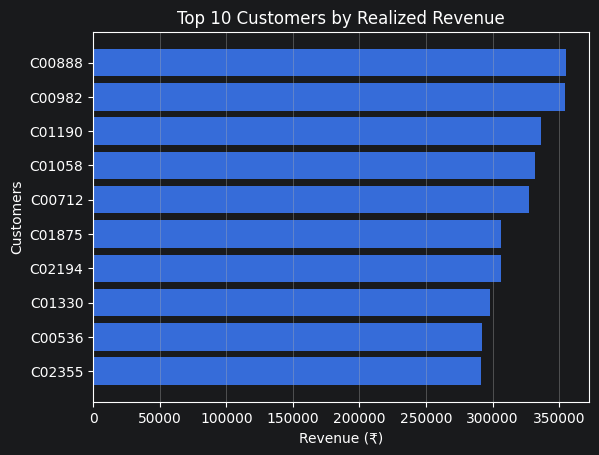

In [435]:
# Top 10 Customers by Realized Revenue

customer_realized_revenue = (
    df.groupby("Customer_ID")["Realized_Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.barh(customer_realized_revenue.index,
         customer_realized_revenue)

plt.xlabel("Revenue (₹)")
plt.ylabel("Customers")
plt.title("Top 10 Customers by Realized Revenue")

plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

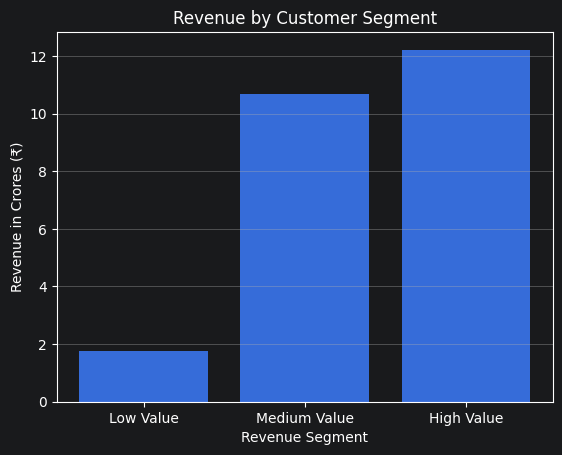

In [436]:
# Revenue by Customer Segment

segment_revenue = (
    customer_revenue.groupby(customer_segment, observed=True)
    .sum()
)

plt.bar(segment_revenue.index,
        segment_revenue / 10_000_000)

plt.xlabel("Revenue Segment")
plt.ylabel("Revenue in Crores (₹)")
plt.title("Revenue by Customer Segment")

plt.grid(axis="y")
plt.show()

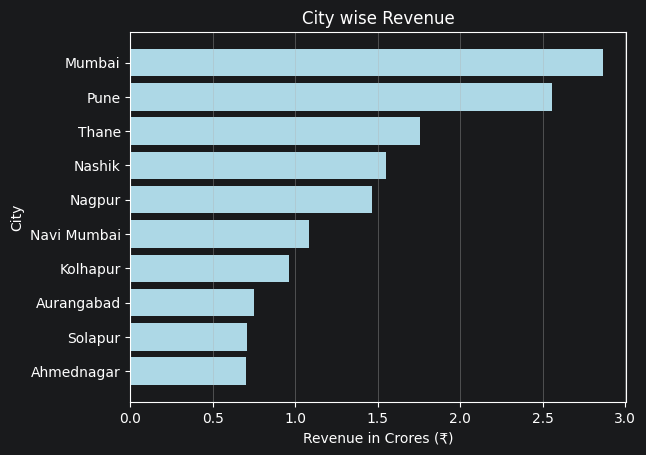

In [437]:
# Revenue By City

city_revenue = df.groupby("City")["Realized_Revenue"].sum().sort_values(ascending=False).head(10)

plt.barh(
    city_revenue.index,
    city_revenue / 10_000_000,
    color = "lightblue"
)

plt.xlabel("Revenue in Crores (₹)")
plt.ylabel("City")
plt.title("City wise Revenue")

plt.gca().invert_yaxis()
plt.grid(axis="x")

plt.show()

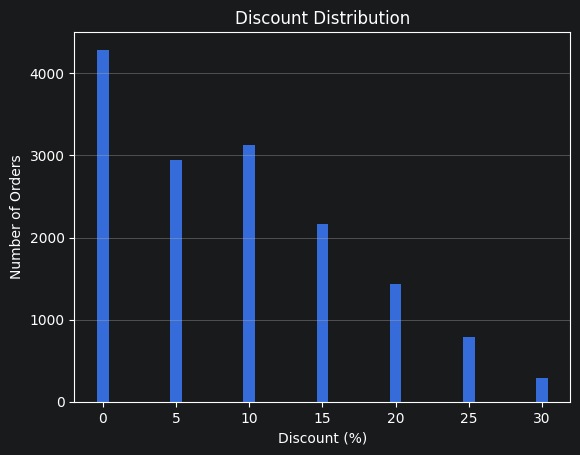

In [438]:
# Discount Distribution

discount_frequency = df["Discount"].value_counts().sort_index()

plt.bar(
    discount_frequency.index,
    discount_frequency
)

plt.xlabel("Discount (%)")
plt.ylabel("Number of Orders")
plt.title("Discount Distribution")

plt.grid(axis="y")

plt.show()

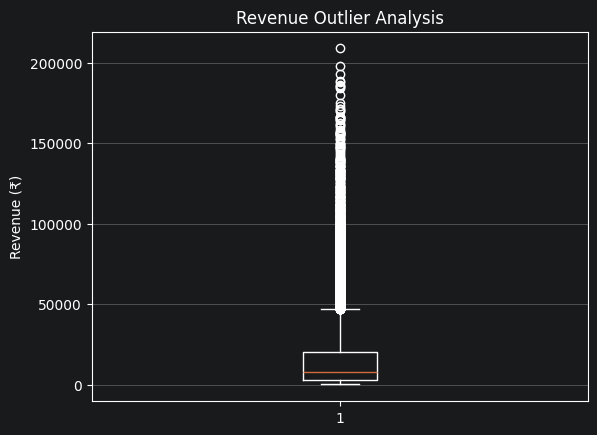

In [439]:
# Revenue Outliers

plt.boxplot(df["Net_Revenue"])

plt.title("Revenue Outlier Analysis")
plt.ylabel("Revenue (₹)")
plt.grid(axis="y")
plt.show()

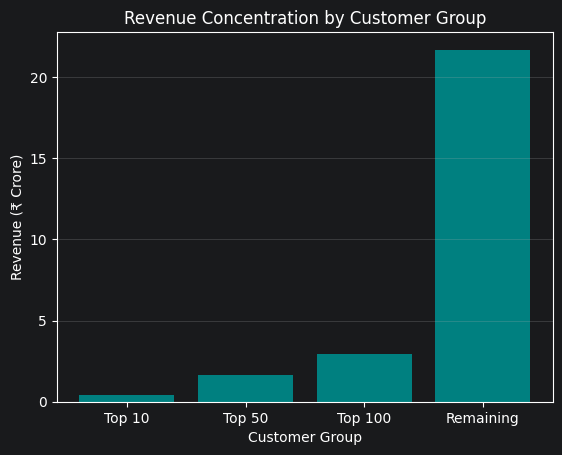

In [440]:
# Revenue Concentration by Customer Groups

top_10_customers = customer_revenue_sorted.head(10).sum()
top_50_customers = customer_revenue_sorted.head(50).sum()
top_100_customers = customer_revenue_sorted.head(100).sum()
remaining_customers = customer_revenue_sorted.sum() - top_100_customers

groups = [
    "Top 10",
    "Top 50",
    "Top 100",
    "Remaining"
]

revenue = [
    top_10_customers,
    top_50_customers,
    top_100_customers,
    remaining_customers
]

plt.bar(
    groups,
    np.array(revenue) / 10_000_000,
    color="teal"
)

plt.xlabel("Customer Group")
plt.ylabel("Revenue (₹ Crore)")
plt.title("Revenue Concentration by Customer Group")
plt.grid(axis="y", alpha=0.3)

plt.show()